<a href="https://colab.research.google.com/github/Chanthul4054/Telco-Customer-Churn-Prediction/blob/main/Course_Work.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Telco Customer Churn Prediciton

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score,confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from imblearn.over_sampling import SMOTE


##Load and Clean Data

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Telco Dataset/Telco-Customer-Churn-dataset.csv')
print(df.shape)
df.info()
df.describe()
display(df.describe(include="all").T)

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)
if 'customerID' in df.columns:
  df.drop('customerID', axis = 1, inplace = True)
if df['Churn'].dtype == 'object':
  df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df.head()

/tmp/ipython-input-345066478.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace = True)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


##Exploratory Data Analysis (EDA)

Numeric Feature Distributions

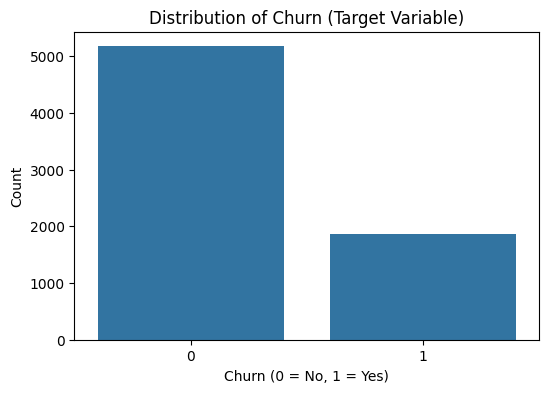

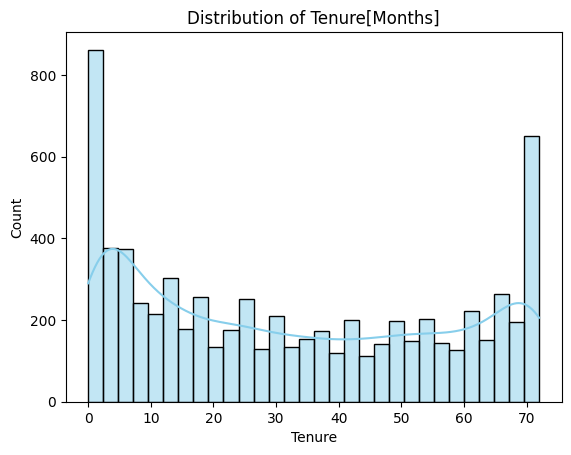

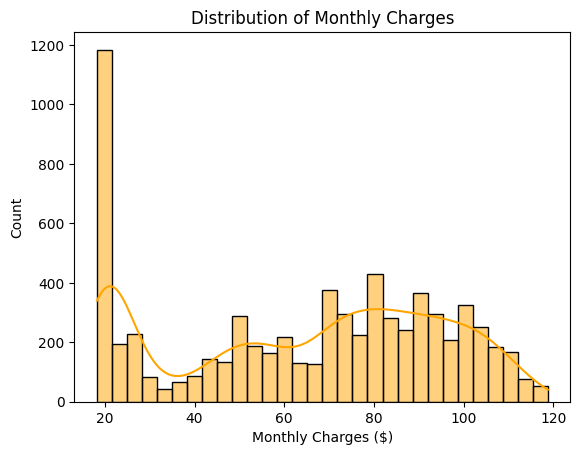

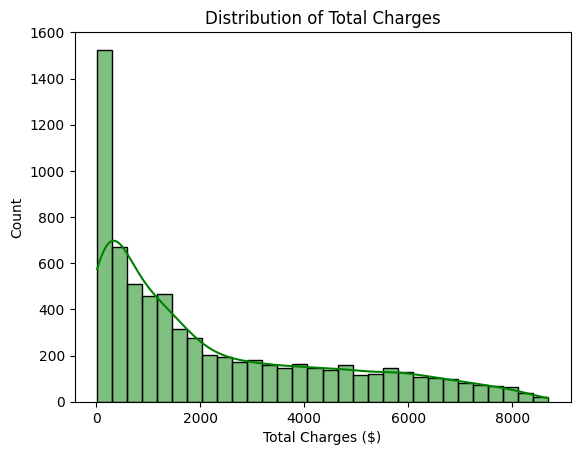

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df)
plt.title('Distribution of Churn (Target Variable)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

sns.histplot(df['tenure'], bins=30, kde=True , color = 'skyblue')
plt.title('Distribution of Tenure[Months]')
plt.xlabel('Tenure')
plt.show()

sns.histplot(df['MonthlyCharges'], bins= 30, kde= True, color = 'orange')
plt.title('Distribution of Monthly Charges')
plt.xlabel('Monthly Charges ($)')
plt.show()

sns.histplot(df['TotalCharges'], bins=30, kde=True, color = 'green')
plt.title('Distribution of Total Charges')
plt.xlabel('Total Charges ($)')
plt.show()

Numerical Features vs. Churn (Box Plots)

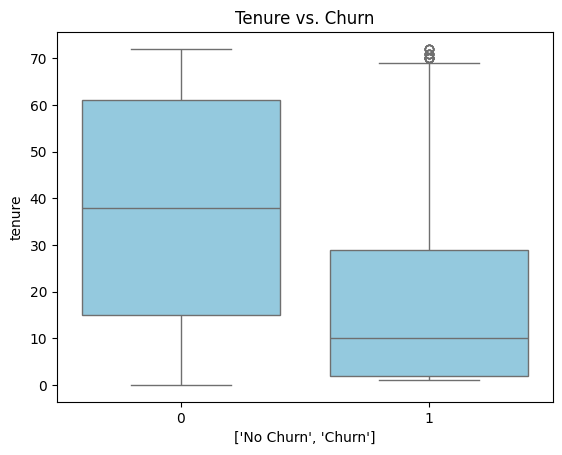

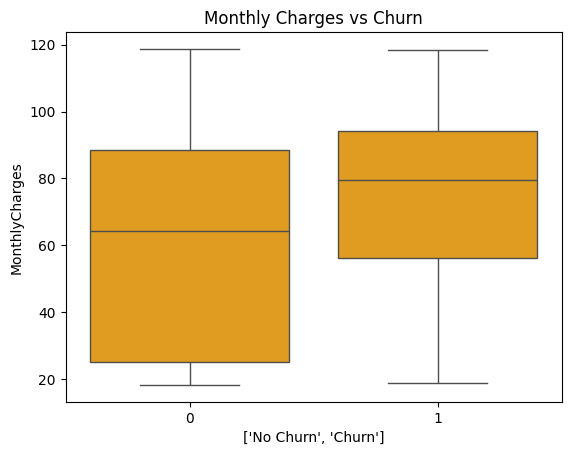

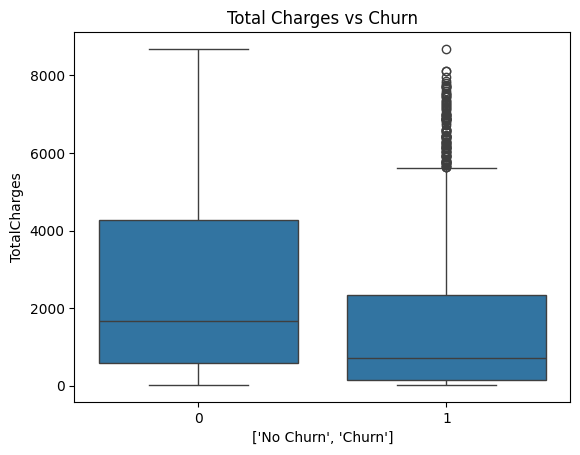

In [5]:
sns.boxplot(x='Churn', y = 'tenure', data =df ,color='skyblue')
plt.title('Tenure vs. Churn')
plt.xlabel(['No Churn' , 'Churn'])
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df , color='orange' )
plt.title('Monthly Charges vs Churn')
plt.xlabel(['No Churn', 'Churn'])
plt.show()

sns.boxplot(x='Churn', y='TotalCharges', data=df )
plt.title('Total Charges vs Churn')
plt.xlabel(['No Churn', 'Churn'])
plt.show()

Categorical Features vs. Churn

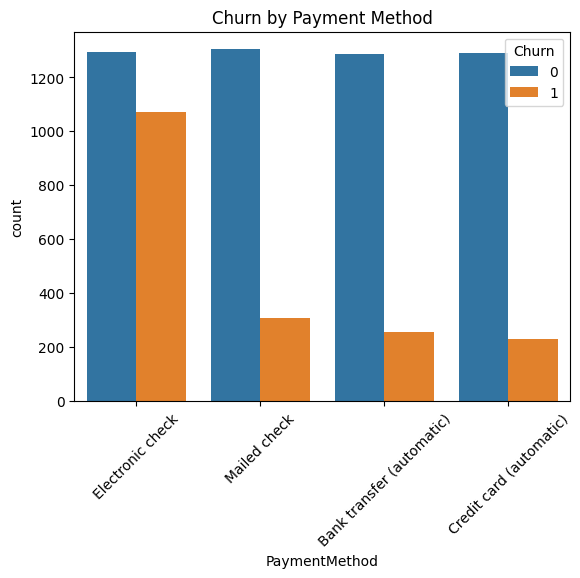

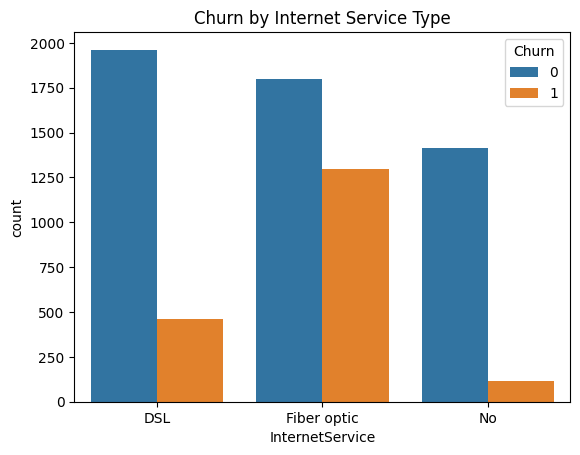

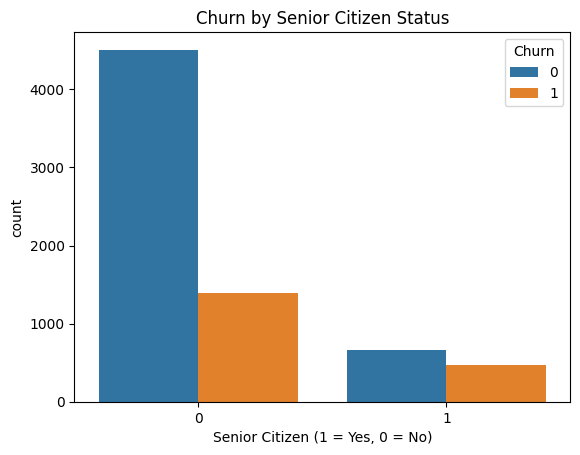

In [6]:
sns.countplot(x='PaymentMethod' , hue = 'Churn', data = df)
plt.title('Churn by Payment Method')
plt.tick_params(axis='x', rotation=45)
plt.show()

sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Churn by Internet Service Type')
plt.show()

sns.countplot(x='SeniorCitizen', hue='Churn', data=df)
plt.title('Churn by Senior Citizen Status')
plt.xlabel('Senior Citizen (1 = Yes, 0 = No)')
plt.show()


#Data Preprocessing

In [7]:
#Separate Features
x = df.drop('Churn', axis = 1)
y = df['Churn']
x = pd.get_dummies(x, drop_first = True)

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2 , random_state=42 , stratify=y )

#scaling
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Original Training Class Distribution:\n", y_train.value_counts())

smote= SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_scaled, y_train)

print("\nSMOTE Applied. New Training Class Distribution:\n", y_train_smote.value_counts())
print(f"\nTraining set shape (after SMOTE): {x_train_smote.shape}")
print(f"Test set shape (original): {x_test_scaled.shape}")

Original Training Class Distribution:
 Churn
0    4139
1    1495
Name: count, dtype: int64

SMOTE Applied. New Training Class Distribution:
 Churn
0    4139
1    4139
Name: count, dtype: int64

Training set shape (after SMOTE): (8278, 30)
Test set shape (original): (1409, 30)


#Decision Tree Model

In [8]:
dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train_smote, y_train_smote)

best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(x_test_scaled)

print(f"Best DT Params: {grid_search.best_params_}")
print("\n--- Decision Tree Classification Report ---")
print(classification_report(y_test, y_pred))

dt_roc_auc = roc_auc_score(y_test, best_dt.predict_proba(x_test_scaled)[:, 1])
print(f"Decision Tree ROC AUC Score: {dt_roc_auc}")



Best DT Params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 10}

--- Decision Tree Classification Report ---
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1035
           1       0.50      0.66      0.57       374

    accuracy                           0.73      1409
   macro avg       0.68      0.71      0.69      1409
weighted avg       0.76      0.73      0.74      1409

Decision Tree ROC AUC Score: 0.7865380144152523


#Neural Network Model

In [12]:
model = keras.Sequential([
    layers.Dense(32, activation='relu' , input_shape=(x_train_scaled.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(16, activation = 'relu'),
    layers.Dense(1, activation='sigmoid')
])

#compile the
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

#train the model
history = model.fit(x_train_smote, y_train_smote, epochs=20 , batch_size=32, validation_split=0.1, verbose=1)

#predict on test set
y_pred_nn_prob = model.predict(x_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype("int32")

#evaluation
print("\n--- Neural Network Classification Report ---")
print(classification_report(y_test, y_pred_nn))

#calculate ROC-AUC
nn_roc_auc = roc_auc_score(y_test, y_pred_nn_prob)
print(f"Neural Network ROC AUC Score: {nn_roc_auc}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6547 - loss: 0.6132 - val_accuracy: 0.7657 - val_loss: 0.5230
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7710 - loss: 0.4854 - val_accuracy: 0.7742 - val_loss: 0.5059
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7769 - loss: 0.4724 - val_accuracy: 0.7899 - val_loss: 0.4808
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7776 - loss: 0.4654 - val_accuracy: 0.7850 - val_loss: 0.4772
Epoch 5/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7727 - loss: 0.4741 - val_accuracy: 0.7862 - val_loss: 0.4827
Epoch 6/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7776 - loss: 0.4575 - val_accuracy: 0.7754 - val_loss: 0.5070
Epoch 7/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7807 - loss: 0.4577 - val_accuracy: 0.7814 - val_loss: 0.4956
Epoch 8/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7867 - loss: 0.4527 - val_accuracy: 0

#Comparison of Results

In [13]:
dt_acc = accuracy_score(y_test, y_pred)
nn_acc = accuracy_score(y_test, y_pred_nn)

print("--- Final Model Comparison ---")
print(f"Decision Tree Accuracy: {dt_acc}")
print(f"Neural Network Accuracy: {nn_acc}")

if nn_acc > dt_acc:
    print("Conclusion: The Neural Network performed better.")
else:
    print("Conclusion: The Decision Tree performed better.")



--- Final Model Comparison ---
Decision Tree Accuracy: 0.7345635202271115
Neural Network Accuracy: 0.7643718949609652
Conclusion: The Neural Network performed better.
